In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install "drive/MyDrive/Master Data Science/TFM/GITHUB/modelado_multidimensional_engagement-0.1.0-py3-none-any.whl"

Mounted at /content/drive
Processing ./drive/MyDrive/Master Data Science/TFM/GITHUB/modelado_multidimensional_engagement-0.1.0-py3-none-any.whl


In [2]:
from src import config
config.WORKPATH = "drive/MyDrive/Master Data Science/TFM/GITHUB"
config.RESULTSPATH = "drive/MyDrive/Master Data Science/TFM/GITHUB/results"

In [3]:
workpath = config.WORKPATH
resultspath = config.RESULTSPATH

In [ ]:
from src.plots import *

In [5]:
df = pd.read_parquet(os.path.join(workpath, "raw", "2019-Nov-cleaned.parquet"))

In [6]:
# Sales funnel
import pandas as pd

# df = tu dataframe RAW

# 1. Crear tabla de sesiones con flags de cada evento
session_funnel = df.pivot_table(
    index='user_session',
    columns='event_type',
    values='event_time',
    aggfunc='count',
    fill_value=0
)

# Convertir a flags (1 si ocurrió al menos una vez)
session_funnel = (session_funnel > 0).astype(int)

# 2. Calcular totales
total_view = session_funnel['view'].sum()
total_cart = session_funnel['cart'].sum()
total_purchase = session_funnel['purchase'].sum()

# 3. Ratios del funnel
ratio_view_to_cart = total_cart / total_view
ratio_cart_to_purchase = total_purchase / total_cart

print("Total sesiones con view:", total_view)
print("Total sesiones con cart:", total_cart)
print("Total sesiones con purchase:", total_purchase)

print("Ratio view → cart:", ratio_view_to_cart)
print("Ratio cart → purchase:", ratio_cart_to_purchase)


Total sesiones con view: 13750660
Total sesiones con cart: 1741107
Total sesiones con purchase: 773214
Ratio view → cart: 0.1266198858818413
Ratio cart → purchase: 0.4440933268317226


/usr/local/lib/python3.12/dist-packages/src/features/plots.py:45: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = df["event_time"].dt.to_period("W").dt.start_time


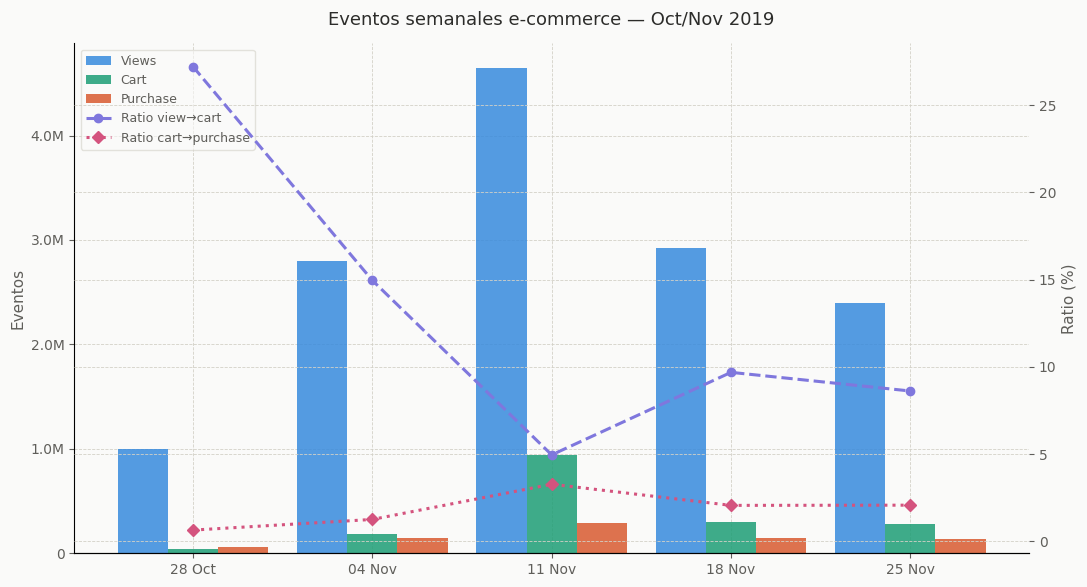

(<Figure size 1100x600 with 2 Axes>,
 event_type       week     view    cart  purchase week_label  \
 0          2019-10-28  1000894   36776     57205     28 Oct   
 1          2019-11-04  2799487  187129    149147     04 Nov   
 2          2019-11-11  4649251  938088    286582     11 Nov   
 3          2019-11-18  2920430  301462    146330     18 Nov   
 4          2019-11-25  2393009  277697    133982     25 Nov   
 
 event_type  ratio_view_to_cart  ratio_cart_to_purchase  
 0                    27.215956                0.642881  
 1                    14.960199                1.254662  
 2                     4.956093                3.273367  
 3                     9.687556                2.060152  
 4                     8.617338                2.072644  )

In [7]:
plot_ecommerce_weekly_chart(
    df,
    output_path=os.path.join(resultspath, "EDA", "ecommerce_weekly_chart.png"),
    show=True
)

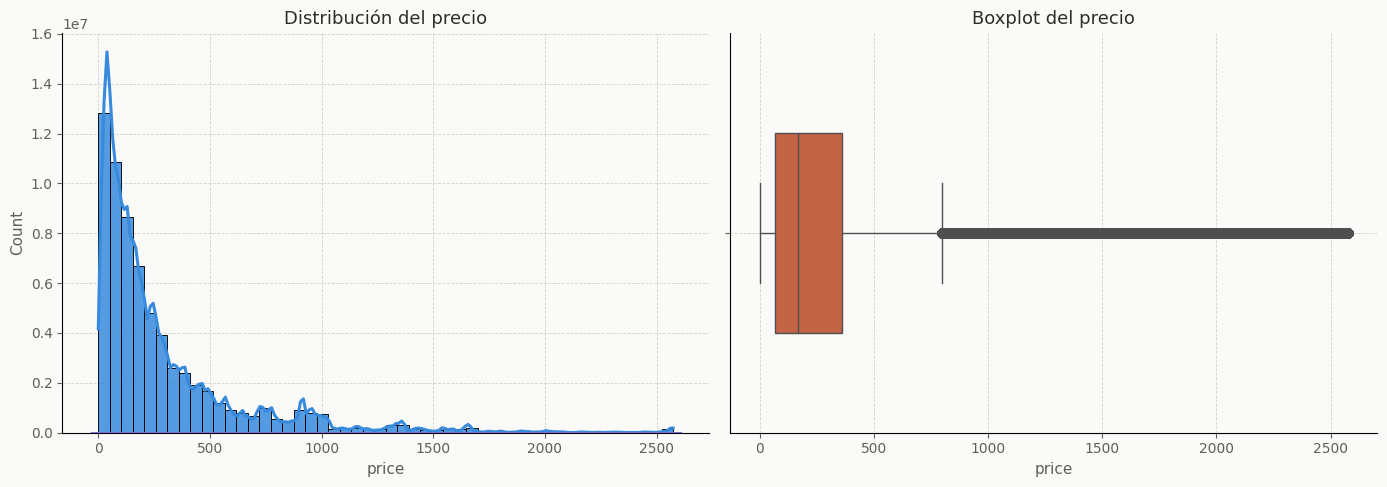

(<Figure size 1400x500 with 2 Axes>,
 (<Axes: title={'center': 'Distribución del precio'}, xlabel='price', ylabel='Count'>,
  <Axes: title={'center': 'Boxplot del precio'}, xlabel='price'>))

In [8]:
plot_price_distribution(
    df,
    output_path=os.path.join(resultspath, "EDA", "plot_price_distribution.png"),
    show=True
)

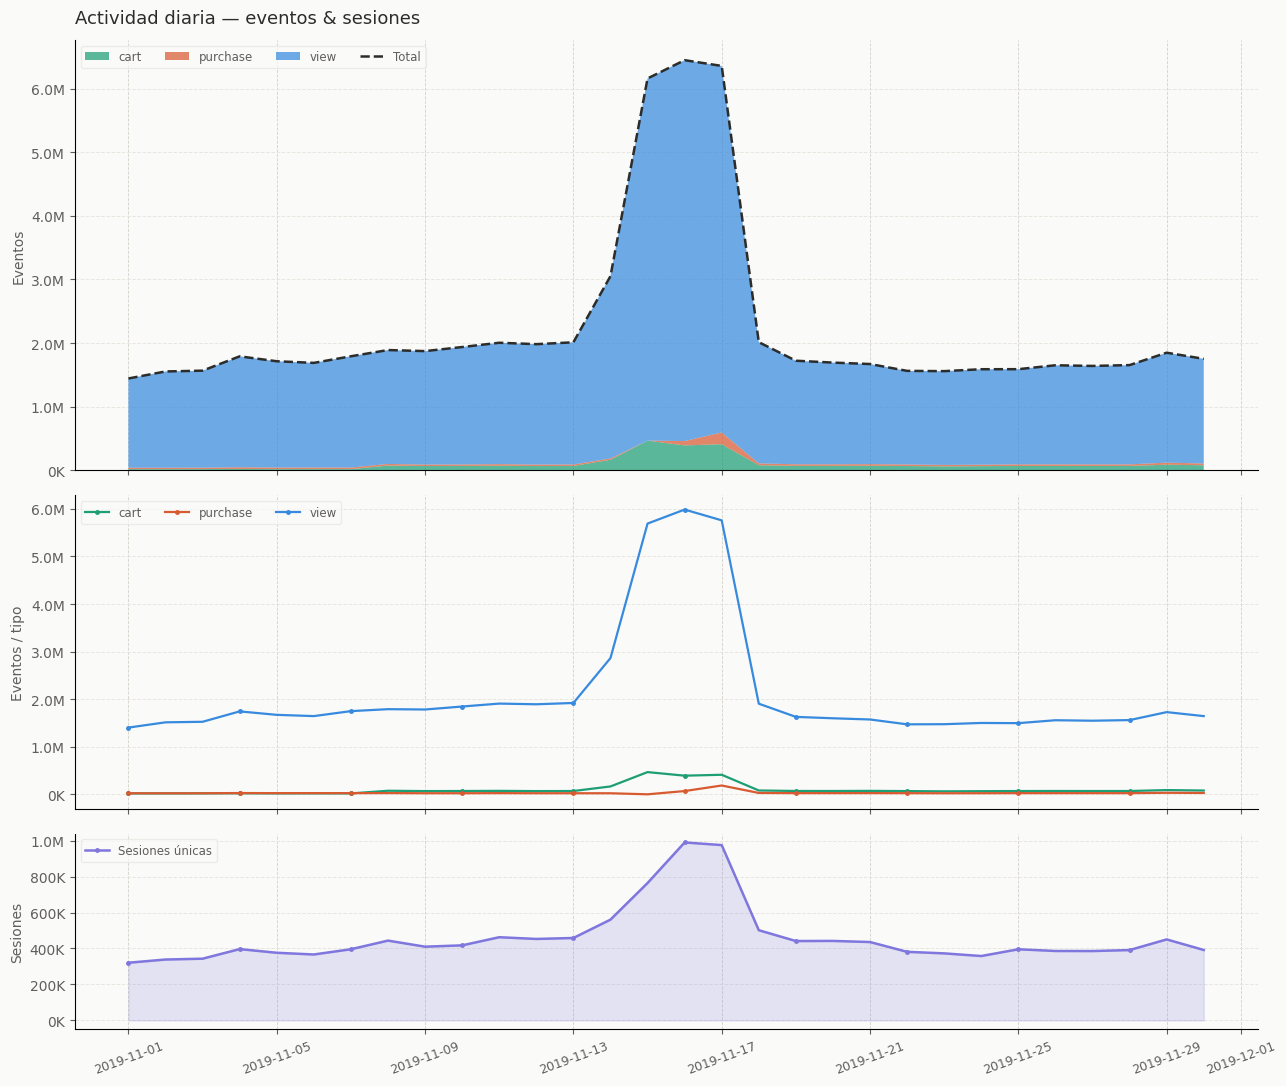

((<Figure size 1300x1100 with 3 Axes>,
  array([<Axes: title={'left': 'Actividad diaria — eventos & sesiones'}, ylabel='Eventos'>,
         <Axes: ylabel='Eventos / tipo'>, <Axes: ylabel='Sesiones'>],
        dtype=object)),
 {'events_per_day': event_day
  2019-11-01    1443517
  2019-11-02    1554010
  2019-11-03    1566425
  2019-11-04    1791533
  2019-11-05    1714258
  2019-11-06    1688752
  2019-11-07    1792525
  2019-11-08    1890390
  2019-11-09    1873683
  2019-11-10    1937794
  2019-11-11    2004990
  2019-11-12    1982960
  2019-11-13    2012118
  2019-11-14    3051728
  2019-11-15    6158587
  2019-11-16    6446119
  2019-11-17    6355722
  2019-11-18    2014453
  2019-11-19    1722750
  2019-11-20    1693164
  2019-11-21    1670638
  2019-11-22    1563226
  2019-11-23    1558981
  2019-11-24    1588950
  2019-11-25    1589815
  2019-11-26    1651064
  2019-11-27    1640727
  2019-11-28    1653820
  2019-11-29    1848702
  2019-11-30    1752072
  Name: total, dtype: int

In [9]:
plot_events_per_day(
    df,
    output_path=os.path.join(resultspath, "EDA", "events_per_day.png"),
    show=True
)

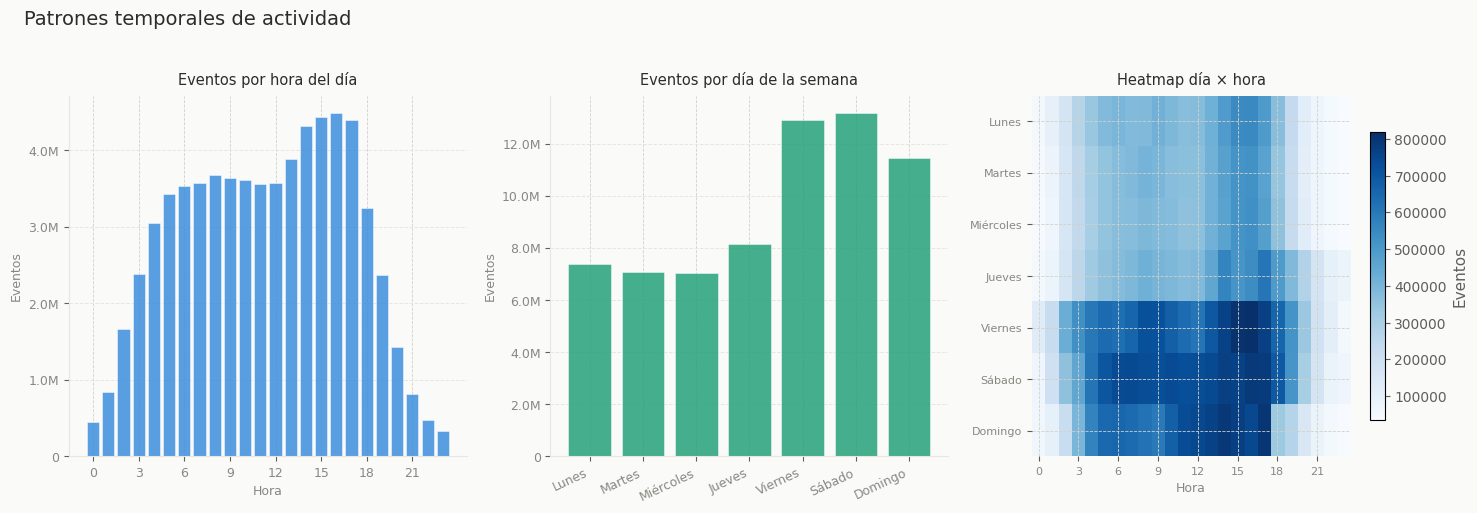

   Guardado: drive/MyDrive/Master Data Science/TFM/GITHUB/results/EDA/patrones_temporales.png



In [10]:
plot_temporal_patterns(
    df,
    output_path=os.path.join(resultspath, "EDA", "patrones_temporales.png"),
    show=True
)

In [26]:
def plot_top_middle_tail(df):
    """
    Visualiza las categorías Top, Middle y Tail siguiendo el estilo TFM.
    - Top 4 categorías más frecuentes
    - Middle 4 categorías del centro de la distribución
    - Tail 10 categorías menos frecuentes
    """
    if "category_code" not in df.columns:
        raise ValueError("El DataFrame debe contener la columna 'category_code'")

    counts = df["category_code"].value_counts()
    if counts.empty:
        raise ValueError("No hay categorías en el DataFrame")

    counts_df = counts.rename_axis("category").reset_index(name="count")

    top4 = counts_df.head(4).assign(group="Top 4")
    middle_start = max((len(counts_df) - 4) // 2, 0)
    middle4 = counts_df.iloc[middle_start: middle_start + 4].assign(group="Middle 4")
    tail10 = counts_df.tail(10).assign(group="Tail 10")

    plot_df = pd.concat([top4, middle4, tail10], ignore_index=True)

    group_colors = {
        "Top 4": COLORS["bars"]["view"],
        "Middle 4": COLORS["bars"]["cart"],
        "Tail 10": COLORS["bars"]["purchase"],
    }

    plt.figure(figsize=(11, 7))
    ax = sns.barplot(
        data=plot_df,
        y="category",
        x="count",
        hue="group",
        palette=group_colors,
        dodge=False,
        alpha=0.85,
    )

    ax.set_xscale("log")
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{int(v):,}" if v >= 1 else str(v)
    ))

    plt.title("Top, Middle y Tail categorías por número de eventos", color=COLORS["title"])
    plt.xlabel("Número de eventos")
    plt.ylabel("Categoría")

    plt.grid(axis="x")
    plt.legend(title="", framealpha=0.6)
    plt.tight_layout()
    plt.show()

    return plot_df

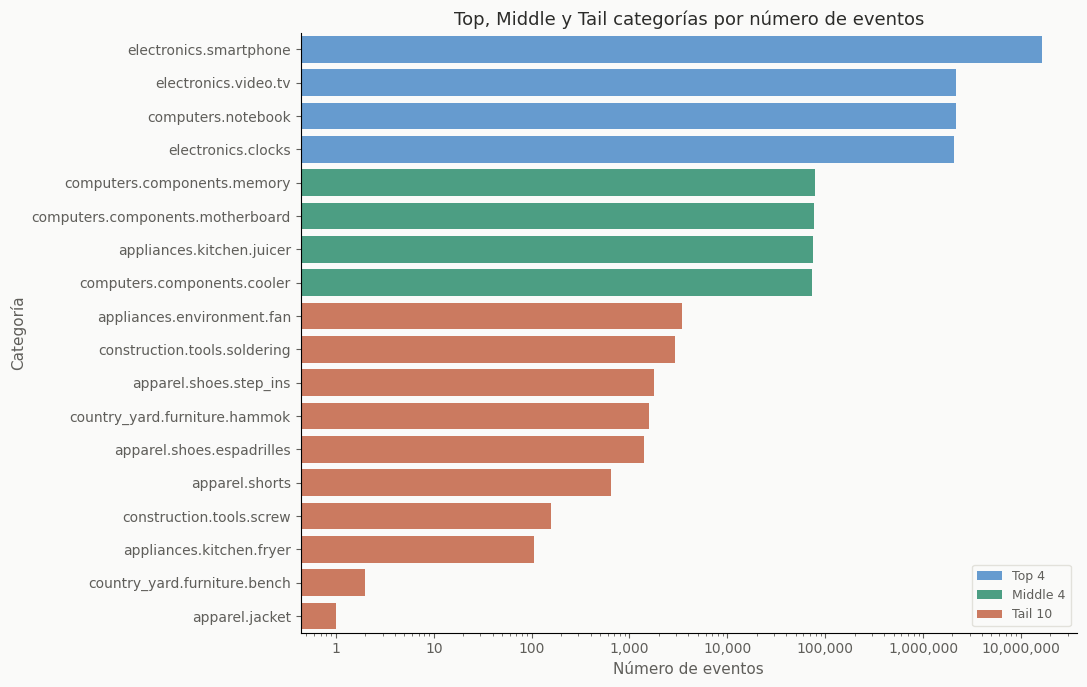

,category,count,group
0,electronics.smartphone,16327481,Top 4
1,electronics.video.tv,2196999,Top 4
2,computers.notebook,2172895,Top 4
3,electronics.clocks,2082491,Top 4
4,computers.components.memory,78696,Middle 4
5,computers.components.motherboard,76116,Middle 4
6,appliances.kitchen.juicer,75066,Middle 4
7,computers.components.cooler,72492,Middle 4
8,appliances.environment.fan,3429,Tail 10
9,construction.tools.soldering,2946,Tail 10


In [27]:
plot_top_middle_tail(df)

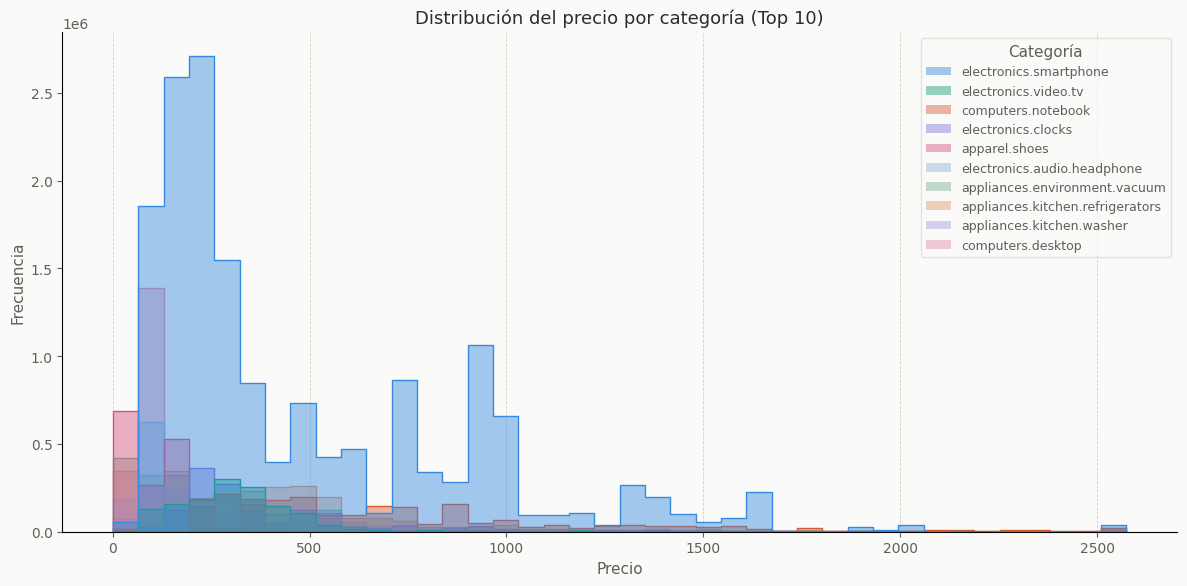

In [38]:
df_top = plot_price_distribution_top10(
    df,
    output_path=os.path.join(resultspath, "EDA", "price_distribution_top10.png"),
    show=True,
)

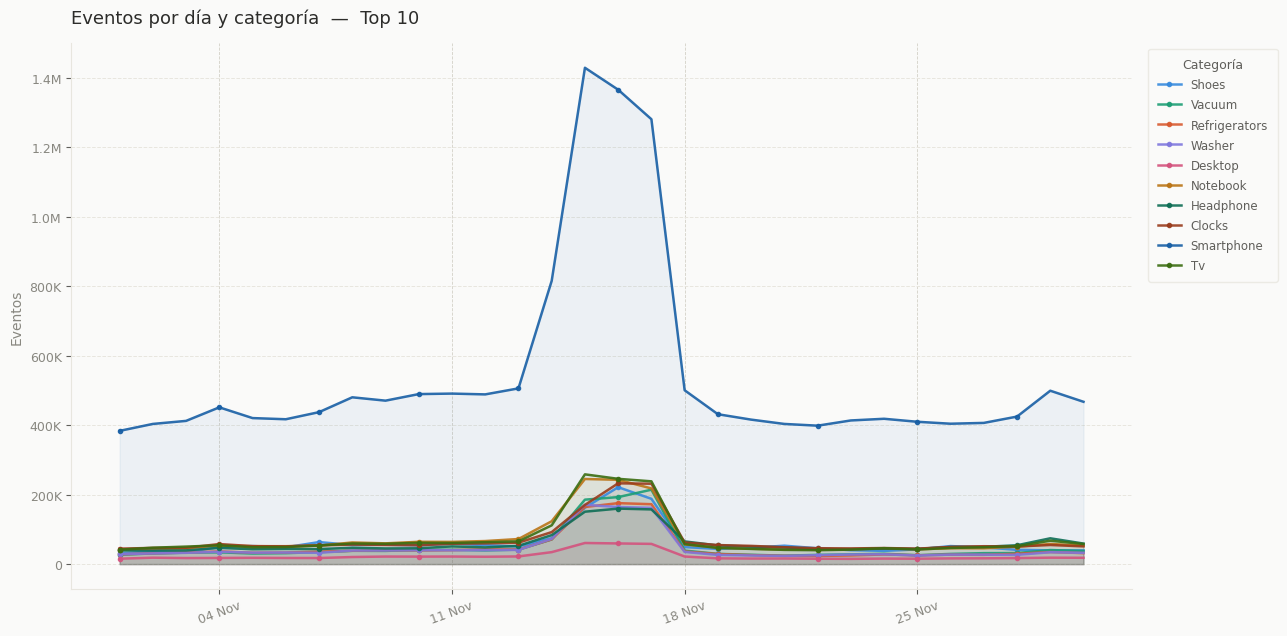

Guardado como drive/MyDrive/Master Data Science/TFM/GITHUB/results/EDA/events_by_category.png


In [23]:
plot_events_by_category_top10(
    df_top,
    show=True,
    output_path=os.path.join(resultspath, "EDA", "events_by_category.png"),
)

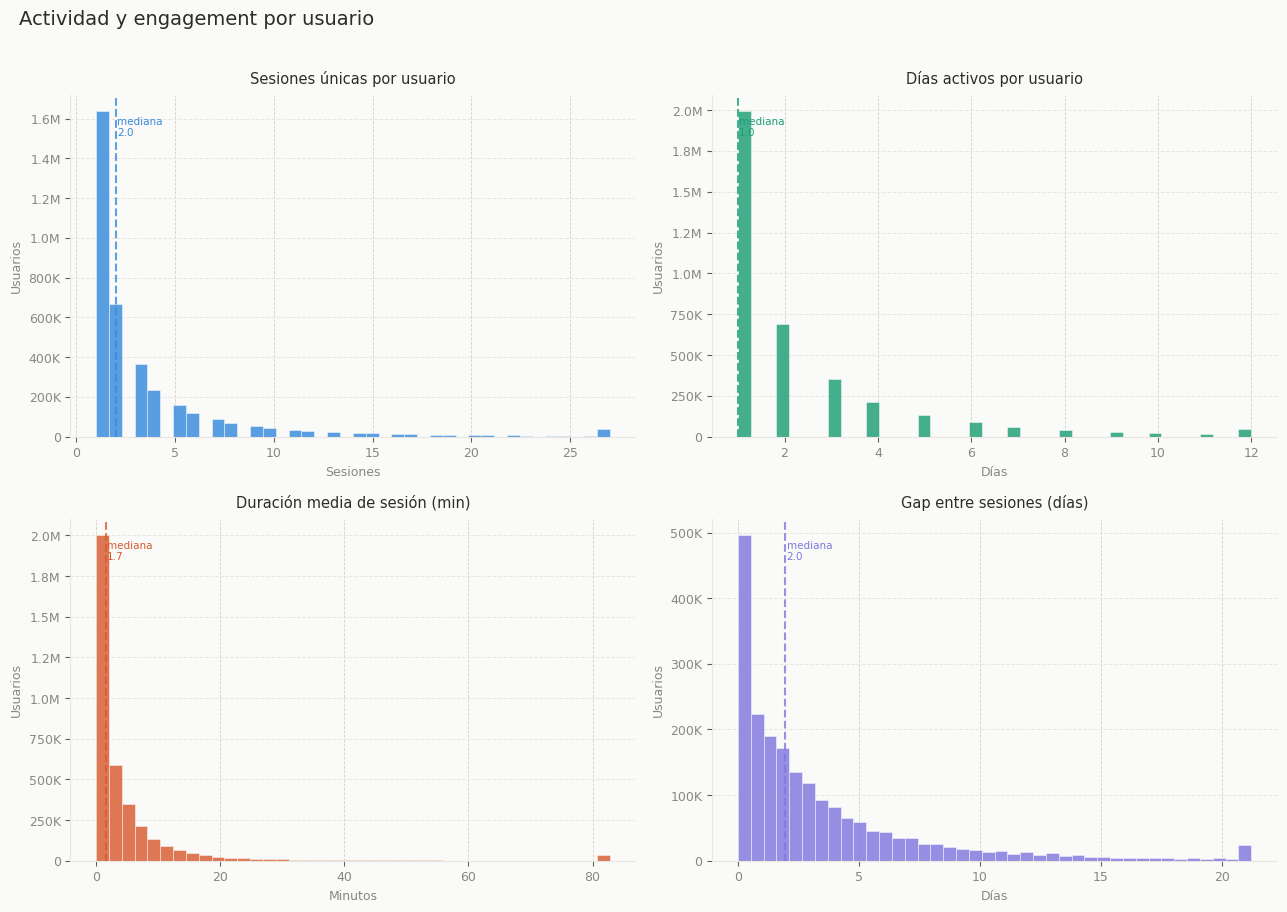

   Guardado: drive/MyDrive/Master Data Science/TFM/GITHUB/results/EDA/actividad_engagement_por_usuario.png



In [14]:
plot_activity_engagement(
    df,
    show=True,
    output_path=os.path.join(resultspath, "EDA", "actividad_engagement_por_usuario.png"),
)

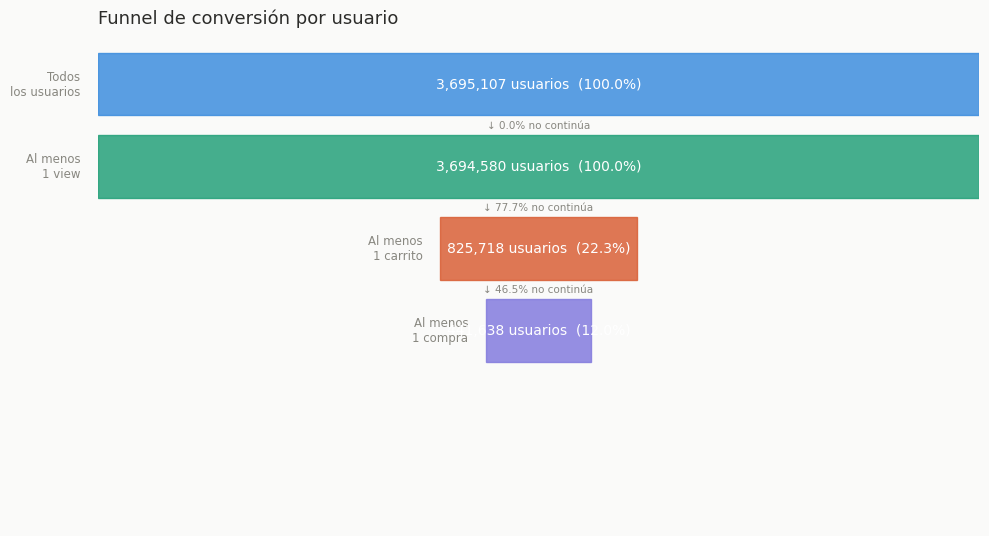

   Guardado: drive/MyDrive/Master Data Science/TFM/GITHUB/results/EDA/funnel_conversion.png



In [15]:
plot_funnel_conversion(
    df,
    show=True,
    output_path=os.path.join(resultspath, "EDA", "funnel_conversion.png"),
)

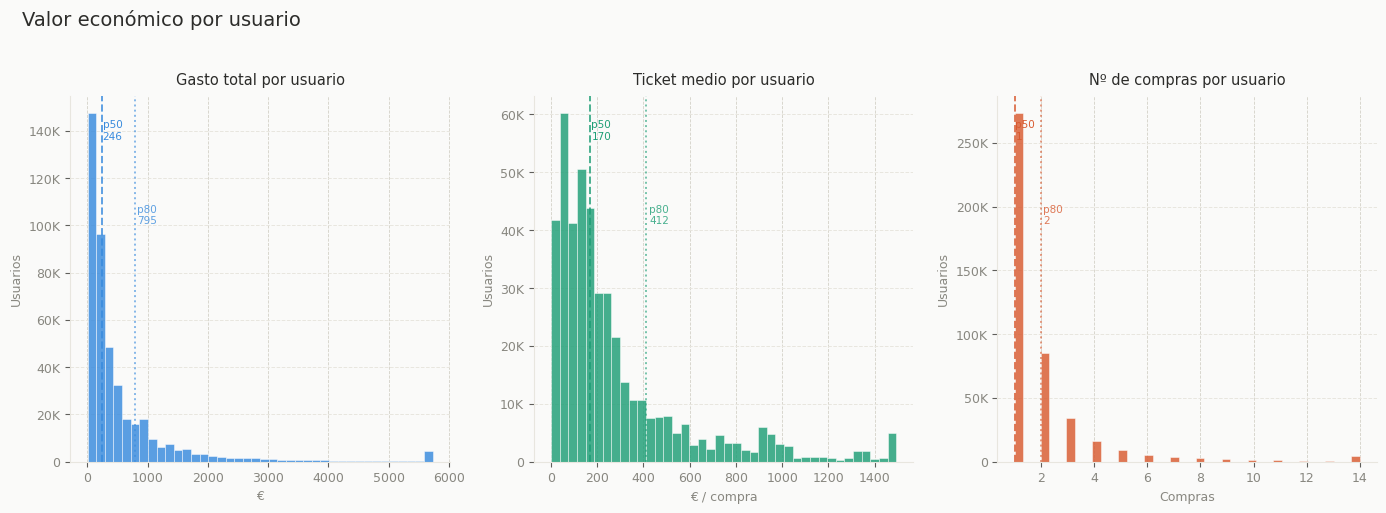

   Guardado: drive/MyDrive/Master Data Science/TFM/GITHUB/results/EDA/valor_economico.png



In [16]:
plot_economic_value(
    df,
    show=True,
    output_path=os.path.join(resultspath, "EDA", "valor_economico.png"),
)

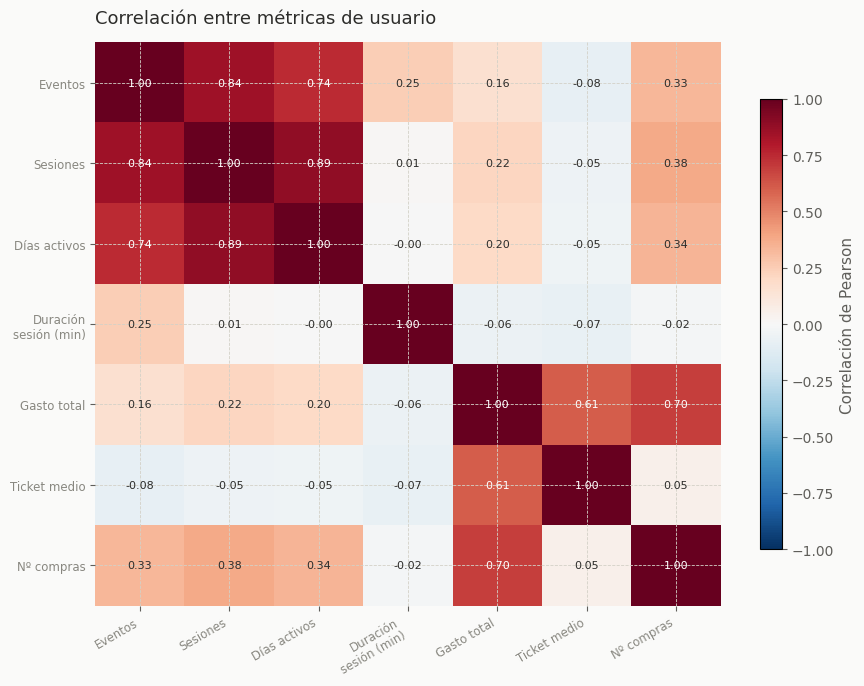

   Guardado: drive/MyDrive/Master Data Science/TFM/GITHUB/results/EDA/corr_heatmap_usuarios.png


In [17]:
plot_corr_user_metrics(
    df,
    show=True,
    output_path=os.path.join(resultspath, "EDA", "corr_heatmap_usuarios.png"),
)

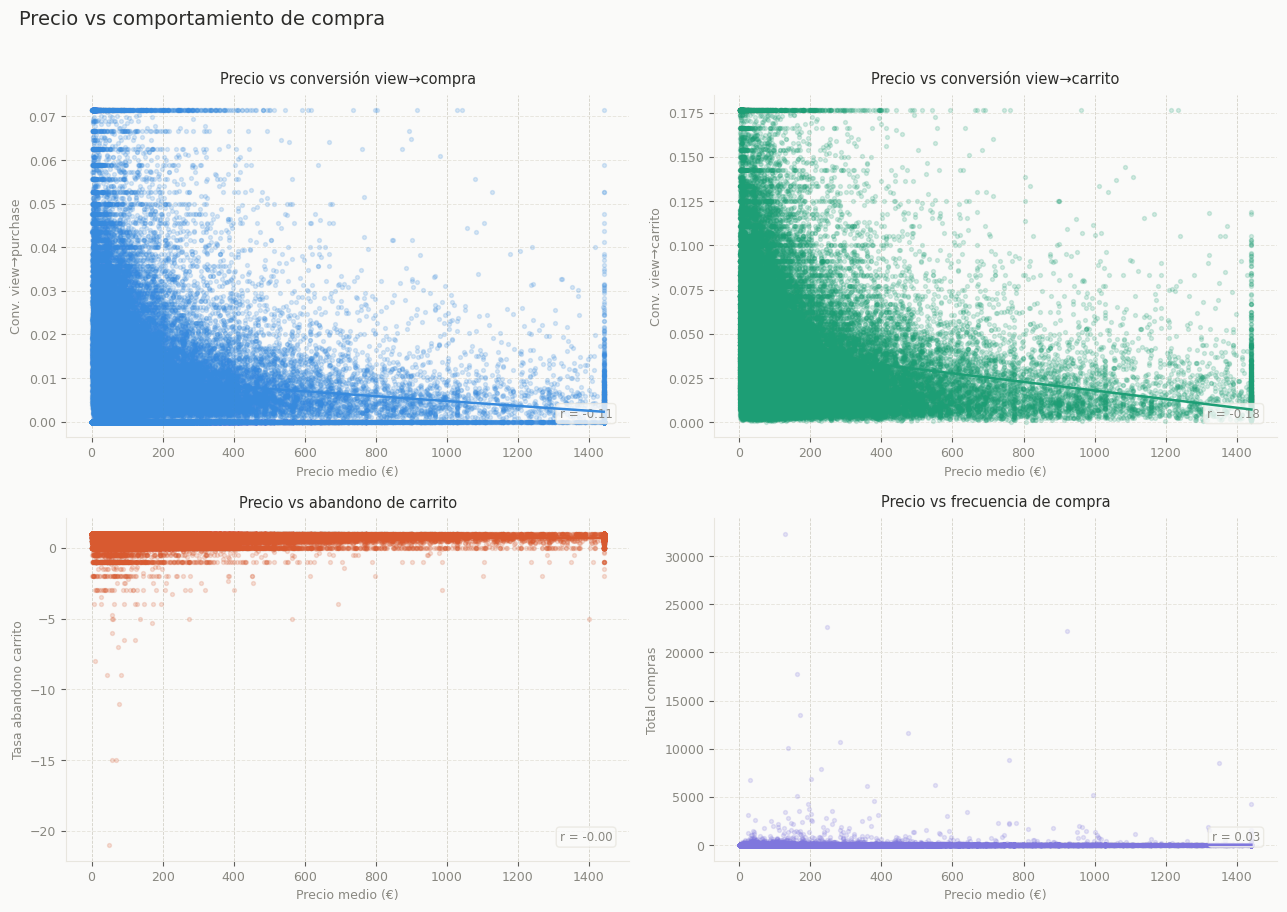

   Guardado: drive/MyDrive/Master Data Science/TFM/GITHUB/results/EDA/corr_precio_comportamiento.png


In [18]:
plot_price_vs_behavior(
    df,
    show=True,
    output_path=os.path.join(resultspath, "EDA", "corr_precio_comportamiento.png"),
)

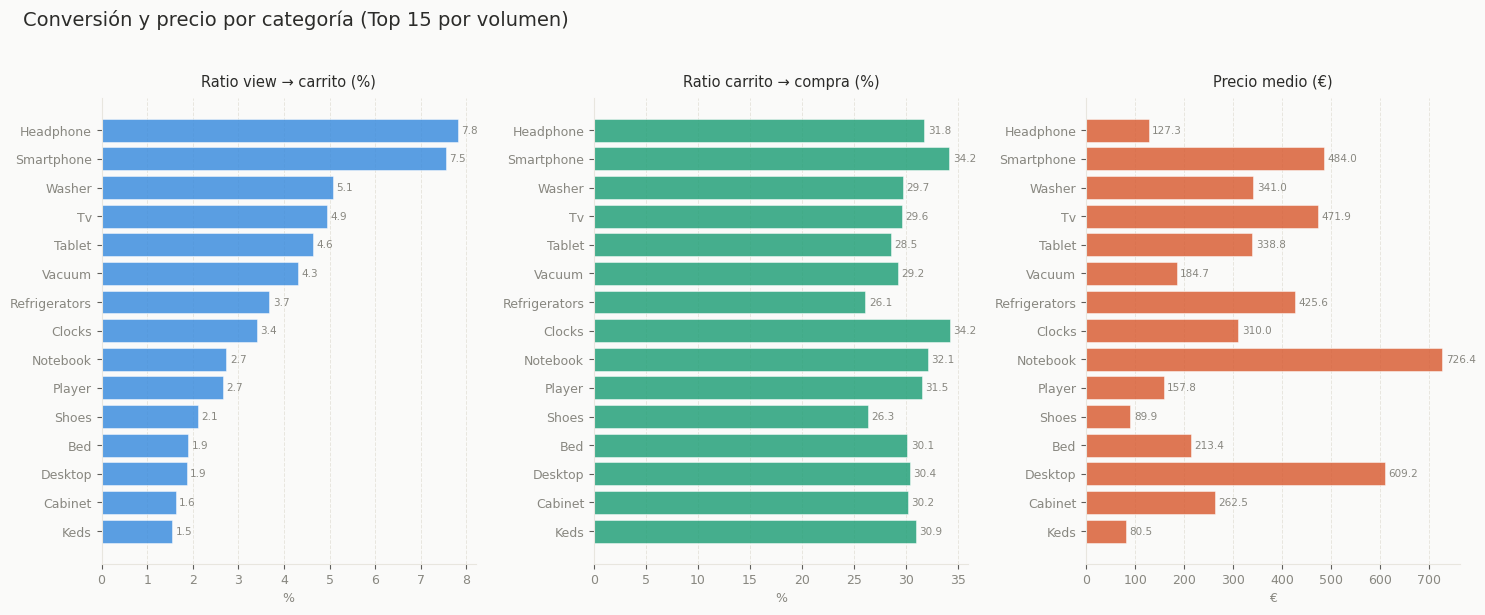

   Guardado: drive/MyDrive/Master Data Science/TFM/GITHUB/results/EDA/corr_ratios_categoria.png


In [19]:
plot_category_ratios(
    df,
    show=True,
    output_path=os.path.join(resultspath, "EDA", "corr_ratios_categoria.png"),
)